In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import time
import matplotlib
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings("ignore")
import matplotlib.dates as mdates
from scipy.stats import norm
!wget -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
matplotlib.font_manager.fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
matplotlib.rc('font', family='Taipei Sans TC Beta')

--2025-04-06 09:47:16--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 173.194.206.102, 173.194.206.138, 173.194.206.101, ...
Connecting to drive.google.com (drive.google.com)|173.194.206.102|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2025-04-06 09:47:16--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 74.125.69.132, 2607:f8b0:4001:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|74.125.69.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘TaipeiSansTCBeta-Regular.ttf’

TaipeiSansTCBeta-Re 100%[===================>]  19.70M  53.9MB/s    in 0.4s    

2025-04-06 09:4

## Q1. VIX Analysis


### (a) Explain the methodology for calculating the VIX (Cboe Volatility Index)

Cboe所計算的VIX通常是以30天期計算，不過實務上不容易剛好有30天到期之選擇權提供計算，因此會需要採用內插法


### 步驟一：選取目標到期日 DTE ≈ 30 的兩個期權合約組

- 設定目標 DTE（如 30 天）
- 在資料中找出最接近該 DTE 的兩個實際到期日（如 27 天與 31 天）
- 分別以這兩個合約計算變異數，最後加權內插得出 VIX



### 步驟二：判斷 ATM 行使價（At-The-Money）

找出買權與賣權價格**差值最小**的行使價 $K$，即為 ATM（平價期權）：

$$
\text{ATM Strike} = \arg\min_{K_i} |C(K_i) - P(K_i)|
$$



### 步驟三：計算遠期價格 $F$

選擇**買權價格與賣權價格差異最小**的行使價作為 ATM 價格 $K$，並計算遠期價格：

$$
F = K + e^{rT} (C - P)
$$

其中：
- $r$ 為無風險利率
- $T$ 為期權到期日與現在的年化時間
- $C$、$P$ 分別為該行使價的買權與賣權價格



### 步驟四：定義 $K_0$ 為小於或等於 $F$ 的最大行使價

$$
K_0 = \max\{K_i \,|\, K_i \leq F\}
$$



### 步驟五：建立 OTM 期權價格序列

- 當 $K_i < K_0$：使用賣權價格 $P_i$
- 當 $K_i > K_0$：使用買權價格 $C_i$
- 當 $K_i = K_0$：使用 $(C_i + P_i)/2$



### 步驟六：計算每個 $K_i$ 的間距 $\Delta K_i$

$$
\Delta K_i =
\begin{cases}
K_1 - K_0, & i = 0 \\
\frac{K_{i+1} - K_{i-1}}{2}, & 0 < i < n \\
K_n - K_{n-1}, & i = n
\end{cases}
$$



### 步驟七：計算變異數 $\sigma^2$

$$
\sigma^2 = \frac{2}{T} \sum_{i} \frac{\Delta K_i}{K_i^2} e^{rT} Q(K_i) - \frac{1}{T} \left( \frac{F}{K_0} - 1 \right)^2
$$

其中：
- $Q(K_i)$ 為對應的 OTM 價格（根據上一步）
- $\Delta K_i$ 為行使價間距
- $T$ 為 DTE 天數除以 365



### 步驟八：若有兩個 DTE，插值得出 30 天變異數

設：
- $\sigma_1^2$ 為前一個到期日變異數，$T_1$ 為其年化天數
- $\sigma_2^2$ 為後一個到期日變異數，$T_2$ 為其年化天數

則插值為：

$$
\sigma^2 = \frac{T_1 \cdot \sigma_1^2 (T_2 - 30/365) + T_2 \cdot \sigma_2^2 (30/365 - T_1)}{T_2 - T_1}
$$



### 步驟九：換算為 VIX 指數

$$
\text{VIX} = 100 \times \sqrt{\sigma^2}
$$





### (b) Plot the time series of both the VIX and the corresponding S&P 500 Index over the same sample period. Analyze and comment on any observed relationship between the two series.

時間從2024/01/02到2024/05/31

In [ ]:
df = pd.read_csv('test_options_data.csv')

In [ ]:
def compute_vix_range(df, start_date, end_date, dte_target=30):

    # 確保日期格式正確
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce').dt.strftime('%Y-%m-%d')

    # 建立結果 DataFrame
    date_range = pd.date_range(start=start_date, end=end_date)
    results = []

    for quote_date in date_range:
        quote = quote_date.strftime('%Y-%m-%d')
        df_quote = df.loc[df['Date'] == quote]

        #遇到假日，則跳過
        if df_quote.empty:
            continue

        # 找最近的 DTE 到期日
        dte1 = df_quote['DTE'].loc[df_quote['DTE'] <= dte_target].max()
        dte2 = df_quote['DTE'].loc[df_quote['DTE'] >= dte_target].min()

        # 如果缺其中一個DTE，則跳過
        if pd.isna(dte1) or pd.isna(dte2):
            continue

        idx1_list = df_quote.loc[df_quote['DTE'] == dte1].index
        idx2_list = df_quote.loc[df_quote['DTE'] == dte2].index

        if len(idx1_list) == 0 or len(idx2_list) == 0:
            continue

        idx1 = idx1_list[0]
        idx2 = idx2_list[0]

        # 分別針對兩個DTE計算其對應的variance(σ²)
        vars_list = []
        nan = np.nan
        for i in [idx1, idx2]:
            try:
                r = df.loc[i, 'r']
                T = df.loc[i, 'DTE'] / 365
                K = np.array(eval(df.loc[i, 'K']))
                call = np.array(eval(df.loc[i, 'c_last']))
                put = np.array(eval(df.loc[i, 'p_last']))

                # 找出ATM
                atm_index = np.where(abs(call - put) == np.nanmin(abs(call - put)))[0]
                atm_K = K[atm_index][0]
                F = atm_K + np.exp(r * T) * (call[atm_index][0] - put[atm_index][0])
                K0 = K[K <= F].max()

                #計算每個Strike對應的OTM價格
                otm_price = np.zeros(len(K))
                otm_price[K < K0] = put[K < K0]
                otm_price[K > K0] = call[K > K0]
                otm_price[K == K0] = (call[K == K0] + put[K == K0]) / 2

                valid = ~np.isnan(otm_price)
                K = K[valid]
                otm_price = otm_price[valid]

                if len(K) < 2:
                    continue

                # 計算 ΔK（間距）
                deltaK = np.zeros(len(K))
                deltaK[0] = K[1] - K[0]
                deltaK[-1] = K[-1] - K[-2]
                deltaK[1:-1] = (K[2:] - K[:-2]) / 2

                # variance(σ²)公式
                contri = (deltaK * otm_price) * np.exp(r * T) / (K ** 2)
                var = 2 * contri.sum() / T - (1 / T) * ((F / K0 - 1) ** 2)

                vars_list.append(var)

            except:
                continue

        if len(vars_list) < 2:
            continue

        var1, var2 = vars_list

        # 用插值法計算 30 天 VIX（若剛好為 30 天，直接取該值）
        if dte1 == dte2:
            VIX = 100 * np.sqrt(var1)
        elif pd.isna(var1) or pd.isna(var2):
            continue
        else:
            p1 = (dte1 / 365) * var1 * (dte2 - dte_target) / (dte2 - dte1)
            p2 = (dte2 / 365) * var2 * (dte_target - dte1) / (dte2 - dte1)
            VIX = 100 * np.sqrt((p1 + p2) * 365 / dte_target)

        results.append({'Date': quote, 'VIX': VIX})

    return pd.DataFrame(results)

In [ ]:
start_date = '2024-01-02'
end_date = '2024-05-31'
VIX = compute_vix_range(df, start_date, end_date, dte_target=30)
VIX['Date'] = pd.to_datetime(VIX['Date']).dt.strftime('%Y-%m-%d')
VIX

,Date,VIX
0,2024-01-02,12.932876
1,2024-01-03,13.520350
2,2024-01-04,13.460244
3,2024-01-05,12.880209
4,2024-01-08,13.044737
...,...,...
100,2024-05-24,11.357228
101,2024-05-28,12.418432
102,2024-05-29,13.340288
103,2024-05-30,13.508954


S&P500指數

In [ ]:
# 設定時間與標的
ticker = "^GSPC"
start_date = "2024-01-02"
end_date = "2024-06-01"

# 下載資料（只抓收盤價）
sp500 = yf.download(ticker, start=start_date, end=end_date, progress=False)
sp500 = sp500.reset_index()[['Date', 'Close']]
sp500['Date'] = pd.to_datetime(sp500['Date']).dt.strftime('%Y-%m-%d')
sp500.columns = sp500.columns.get_level_values(0)

YF.download() has changed argument auto_adjust default to True


合併VIX與S&P500指數資料

In [ ]:
merged_df = pd.merge(VIX, sp500, on='Date', how='inner')

# 確保 merged_df['Date'] 是 datetime 格式
merged_df['Date'] = pd.to_datetime(merged_df['Date'])
merged_df

,Date,VIX,Close
0,2024-01-02,12.932876,4742.830078
1,2024-01-03,13.520350,4704.810059
2,2024-01-04,13.460244,4688.680176
3,2024-01-05,12.880209,4697.240234
4,2024-01-08,13.044737,4763.540039
...,...,...,...
100,2024-05-24,11.357228,5304.720215
101,2024-05-28,12.418432,5306.040039
102,2024-05-29,13.340288,5266.950195
103,2024-05-30,13.508954,5235.479980


繪製VIX與S&P500指數在2024-01-02~2024-05-31

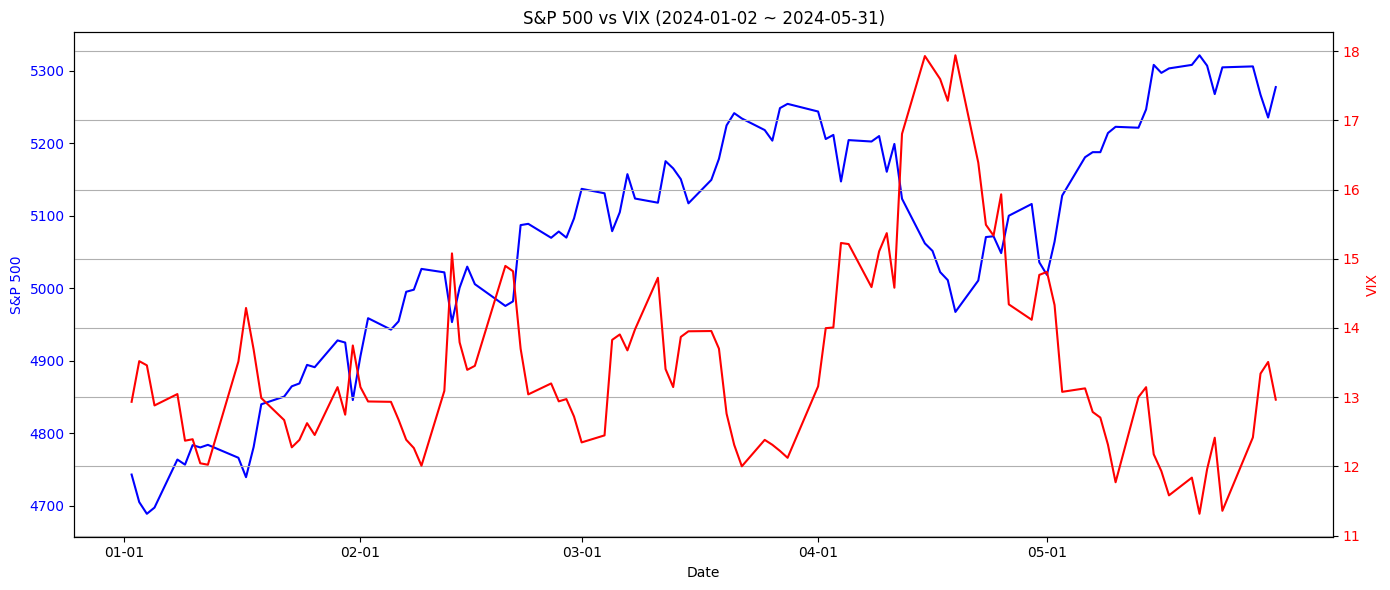

In [ ]:
# 建立每月第一天作為刻度
ticks = pd.date_range(start='2024-01-01', end='2024-05-31', freq='MS')

# 繪製圖形
fig, ax1 = plt.subplots(figsize=(14, 6))

# S&P 500 左軸
ax1.plot(merged_df['Date'], merged_df['Close'], label='S&P 500 (Close)', color='blue')
ax1.set_xlabel('Date')
ax1.set_ylabel('S&P 500', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# 設定 x 軸主刻度
ax1.set_xticks(ticks)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
plt.setp(ax1.get_xticklabels(), rotation=0)

# VIX 右軸
ax2 = ax1.twinx()
ax2.plot(merged_df['Date'], merged_df['VIX'], label='VIX', color='red')
ax2.set_ylabel('VIX', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('S&P 500 vs VIX (2024-01-02 ~ 2024-05-31)')
fig.tight_layout()
plt.grid(True)
plt.show()

## Q2. Implied Volatility (IV) Calibration

### (a) Describe the procedure for IV calibration using the wing model with the weighted least squares method.

#### 步驟1：**資料前處理**  
   - 擷取某一交易日的 S&P 500 指數期權資料（含 Call、Put 價格），並篩選履約價落在平價附近（如 90%～110%）的選擇權。
   - 使用 Black-Scholes 模型搭配二分法（Bisection）反推出各履約價對應的 Implied Volatility（IV）。

---


#### 步驟2：**構造 OTM IV 曲線**  
   - 選擇價外（OTM）的期權價格：履約價低於現價使用 Put IV，履約價高於現價使用 Call IV。
   - 得到 OTM IV 對應履約價的一組資料點 $(K_i, IV_i)$。

---
#### 步驟3：**建立 Wing Model（設計矩陣）**  
   使用二次多項式表示 IV 曲線：
   $$
   IV(K) = \beta_0 + \beta_1 K + \beta_2 K^2
   $$
   將其轉換為線性回歸問題，令設計矩陣 $A = [1, K, K^2]$，目標變數為 $IV$。

---

#### 步驟4：**設定權重矩陣 $W$（反比型設計）**  
   為強調平價附近（ATM）資料點的重要性，我們選擇以下形式作為權重：
   $$
   w_i = \frac{1}{|K_i - S_0| + \epsilon}
   $$
   其中 $\epsilon$ 為極小值（如 $10^{-6}$），避免除以零錯誤。

   此種反比型權重能夠快速放大距離平價越近的觀察點的重要性，使模型更專注於擬合 IV 微笑曲線的中心區域。實務上，IV 曲線在平價附近變化劇烈，而該區域亦具有最高的市場成交量與資訊價值，因此此種設計能有效提升模型在核心區段的擬合準確度。相比 Gaussian 權重的平滑分配，反比型權重在本案例中實證效果更佳，能進一步降低加權誤差（WMSE）。

---

#### 步驟5：**估計模型參數**  
   套用加權最小平方法（WLSM）求解參數 $\beta$：
   $$
   \hat{\beta} = (A^T W A)^{-1} A^T W y
   $$
   得到一條平滑的 Implied Volatility 曲線。








In [ ]:
# BS Model
def bls(s,k,r,t,sig):
    d1 = (np.log(s/k) + (r+sig**2/2)*t)/(sig*np.sqrt(t))
    d2 = (np.log(s/k) + (r-sig**2/2)*t)/(sig*np.sqrt(t))
    call = s * norm.cdf(d1) - k * np.exp(-r*t) * norm.cdf(d2)
    put = k * np.exp(-r*t) * norm.cdf(-d2) - s * norm.cdf(-d1)
    return call, put

# 用二分法去逼近求出IV解
def bisection_call_iv(s,k,r,t,call):
    tol = 0.000001 # 容許誤差
    p1 = np.zeros(len(k)) # 初始下界
    p2 = np.ones(len(k))*10 # 初始上界
    for m in range(50): # 進行最多50次迭代
        sig = (p1+p2)/2.0 # 二分法
        callbs = bls(s, k, r, t, sig)[0]
        if (abs(callbs-call) < tol).all():
            break
        index1 = callbs >= call
        index2 = callbs <= call
        p2[index1] = sig[index1]
        p1[index2] = sig[index2]
    return p1    # 隱含波動率

def bisection_put_iv(s,k,r,t,put):
    tol = 0.000001
    p1 = np.zeros(len(k))
    p2 = np.ones(len(k))*10
    for m in range(50):
        sig = (p1+p2)/2.0
        putbs = bls(s, k, r, t, sig)[1]
        if (abs(putbs-put) < tol).all():
            break
        index1 = putbs >= put
        index2 = putbs <= put
        p2[index1] = sig[index1]
        p1[index2] = sig[index2]
    return p1

In [ ]:
# i 可帶入不同數值去觀察
i=5
# Calculate Implied Volatility
df = pd.read_csv('test_options_data.csv')
nan = np.nan
date = df.loc[i,'Date']
expire = df.loc[i,'expiration_date']
S0 = df.loc[i,'S0']
K = np.array(eval(df.loc[i,'K']))
r = df.loc[i,'r']
T = df.loc[i,'DTE']/365
call = np.array(eval(df.loc[i,'c_last']))
put = np.array(eval(df.loc[i,'p_last']))

# 設定履約、買權、賣權價格在平價選擇權附近
call = call[(K>=S0*0.9)&(K<=S0*1.1)]
put = put[(K>=S0*0.9)&(K<=S0*1.1)]
K = K[(K>=S0*0.9)&(K<=S0*1.1)]

# --- 計算 call/put 的 IV 曲線 ---
put_iv = bisection_put_iv(S0, K, r, T, put)
call_iv = bisection_call_iv(S0, K, r, T, call)

# OTM option IV 建構
index1 = (K <= S0)
index2 = (K > S0)
otm_iv = np.zeros(len(K))
otm_iv[index1] = put_iv[index1]
otm_iv[index2] = call_iv[index2]
K = K[otm_iv != 0]
otm_iv = otm_iv[otm_iv != 0]
A = np.array([np.ones(len(K)), K, np.square(K)]).T

### (b) Define the metrics used to measure the error in IV calibration.

在這次的IV Calibration中，使用 **加權平均平方誤差（Weighted Mean Squared Error, WMSE）** 作為主要的誤差衡量指標。WMSE 可以有效評估模型推導出的隱含波動率與市場實際觀察到的隱含波動率之間的差異，並依據每筆資料的重要性賦予不同權重。

WMSE 的計算公式如下：

$$
\text{WMSE} = \frac{\sum_{i=1}^{N} w_i \cdot \left( \sigma^{\text{model}}_i - \sigma^{\text{market}}_i \right)^2}{\sum_{i=1}^{N} w_i}
$$

其中：

- $\sigma^{\text{model}}_i$：第 $i$ 筆資料由模型產生的隱含波動率；
- $\sigma^{\text{market}}_i$：第 $i$ 筆資料由市場觀察到的隱含波動率；
- $w_i$：第 $i$ 筆資料的權重，常依據選擇權的流動性、買賣價差或 moneyness 分配；
- $N$：總觀察資料筆數。

使用 WMSE 能夠讓模型在校準時更重視關鍵的價格資訊，進而提升整體 IV 曲面的擬合效果與實用性。

**在誤差衡量部分，我們為確保 WLSM 模型擬合效果能被公平比較，亦將相同的加權誤差指標（WMSE）套用至 LSM 模型的擬合結果。如此可避免因權重設計不同而導致誤差指標不可比的情況，使兩種模型能在同一基準下進行準確評估。**



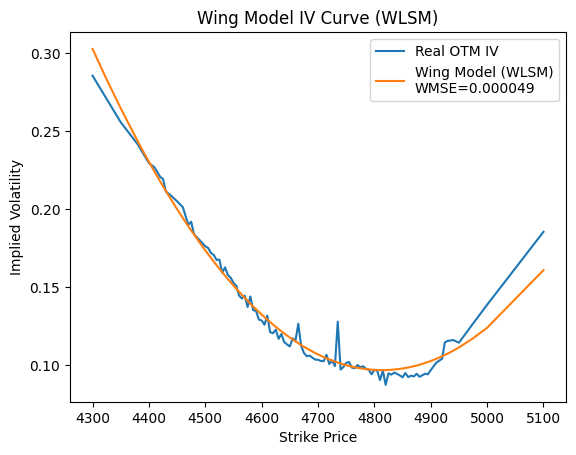

In [ ]:
# --- 權重設為 1 / |K - S0|，避免除以0（加上微小常數），離 S0 越近，權重越大（強調平價區）---
weights = 1 / (np.abs(K - S0) + 1e-6)
W = np.diag(weights)

# --- 加權最小平方法（WLSM） ---
wls_coef = np.linalg.inv(A.T @ W @ A) @ (A.T @ W @ otm_iv)

# --- 計算 WMSE 誤差 ---
iv_fit = A @ wls_coef
wmse = np.sum(weights * (otm_iv - iv_fit) ** 2) / np.sum(weights)

# --- 畫圖 ---
plt.plot(K, otm_iv, '-', label='Real OTM IV')
plt.plot(K, iv_fit, '-', label=f'Wing Model (WLSM)\nWMSE={wmse:.6f}')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.title('Wing Model IV Curve (WLSM)')
plt.legend()
plt.show()

### (c) Compare the calibration errors obtained from the wing model versus the pure least squares method.

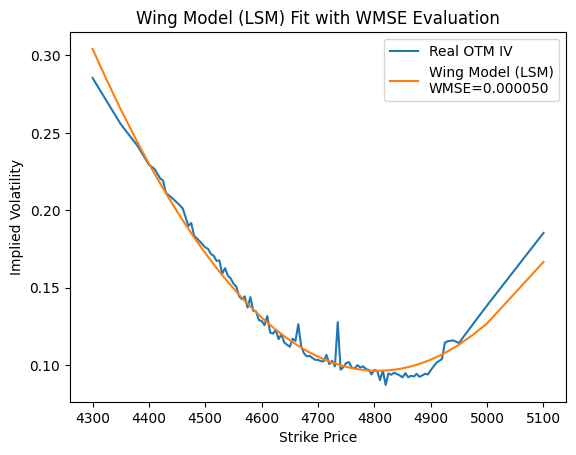

In [ ]:
# OLS（LSM）模型擬合
ols_coef = np.linalg.inv(A.T @ A) @ A.T @ otm_iv
iv_pred_ols = A @ ols_coef

# 計算誤差（residuals）
residuals_ols = otm_iv - iv_pred_ols

# 改成使用與 WLSM 相同的 weights 計算 WMSE
weights = 1 / (np.abs(K - S0) + 1e-6)  # 保持一致
wmse_ols = np.sum(weights * residuals_ols**2) / np.sum(weights)

# 繪圖
plt.plot(K, otm_iv, '-', label='Real OTM IV')
plt.plot(K, iv_pred_ols, '-', label=f'Wing Model (LSM)\nWMSE={wmse_ols:.6f}')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.title('Wing Model (LSM) Fit with WMSE Evaluation')
plt.legend()
plt.show()

首先以特定日期做觀察兩者Errors相差之圖形，可觀察到 WLSM 模型在平價區域（如 K ≈ S₀ 附近）的誤差普遍小於 LSM，表示其能更有效擬合市場最關注的 ATM IV。然而，在遠離平價的深價內或價外履約價區域（如 4300 或 5100），WLSM 由於權重較低，導致殘差略高於 OLS 模型，形成明顯的 tail effect。

整體而言，WLSM 以犧牲尾端貼合為代價，換取平價區域的更高擬合精度，符合期權市場重視 ATM 區域波動率表現的實務需求。


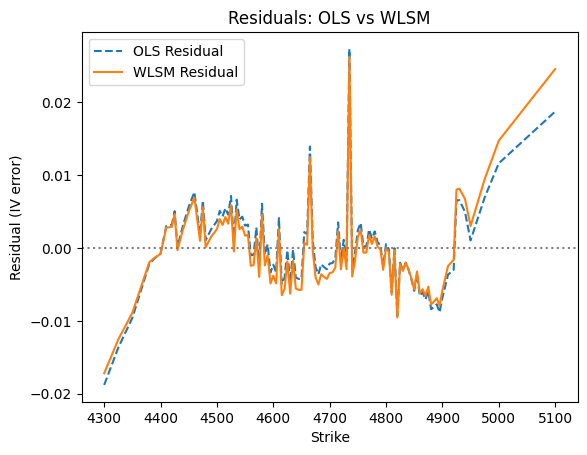

In [ ]:
residual_ols = otm_iv - (A @ ols_coef)
residual_wls = otm_iv - iv_fit

plt.plot(K, residual_ols, label='OLS Residual', linestyle='--')
plt.plot(K, residual_wls, label='WLSM Residual', linestyle='-')
plt.axhline(0, color='gray', linestyle=':')
plt.xlabel('Strike')
plt.ylabel('Residual (IV error)')
plt.title('Residuals: OLS vs WLSM')
plt.legend()
plt.show()

接者，針對 2024/01/02 至 2024/05/31 期間每日的期權資料，分別以普通最小平方法（LSM）與加權最小平方法（WLSM）進行 IV 曲線擬合，並統一以 Weighted Mean Squared Error（WMSE）作為誤差衡量指標。

結果顯示，大多數交易日中，WLSM 相較於 LSM 更能有效降低加權誤差。在 2,773 筆交易日樣本中，我們計算每一筆資料的誤差差異 $$
\text{WMSE}_{\text{LSM}} - \text{WMSE}_{\text{WLSM}}
$$，並取其平均，得到：

$$
\text{平均誤差差異（LSM - WLSM）} = 0.00000631
$$

此結果驗證加權模型在針對平價履約價區域進行擬合時，稍微具備更高準確度，特別是在市場 IV 曲線於該區出現劇烈變化的情境下。

In [ ]:
wmse_lsm_list = []
wmse_wlsm_list = []
dates = []

for i in range(len(df)):  # 每一天一筆資料
    try:
        # 1. 讀入當天資料
        S0 = df.loc[i, 'S0']
        K = np.array(eval(df.loc[i, 'K']))
        r = df.loc[i, 'r']
        T = df.loc[i, 'DTE'] / 365
        call = np.array(eval(df.loc[i, 'c_last']))
        put = np.array(eval(df.loc[i, 'p_last']))
        date = df.loc[i, 'Date']  # 可選擇使用日期當作 index

        # 2. 篩選平價附近
        mask = (K >= S0 * 0.9) & (K <= S0 * 1.1)
        K = K[mask]
        call = call[mask]
        put = put[mask]

        if len(K) < 5:  # 資料太少跳過
            continue

        # 3. 計算 IV
        call_iv = bisection_call_iv(S0, K, r, T, call)
        put_iv = bisection_put_iv(S0, K, r, T, put)
        otm_iv = np.where(K <= S0, put_iv, call_iv)

        valid = otm_iv != 0
        K_valid = K[valid]
        iv_valid = otm_iv[valid]

        if len(K_valid) < 5:
            continue

        # 4. 建立設計矩陣 & 權重
        A = np.vstack([np.ones(len(K_valid)), K_valid, K_valid**2]).T
        weights = 1 / (np.abs(K_valid - S0) + 1e-6)
        W = np.diag(weights)

        # 5. LSM 擬合 + WMSE 評估
        ols_coef = np.linalg.inv(A.T @ A) @ A.T @ iv_valid
        iv_pred_ols = A @ ols_coef
        wmse_lsm = np.sum(weights * (iv_valid - iv_pred_ols)**2) / np.sum(weights)

        # 6. WLSM 擬合 + WMSE 評估
        wls_coef = np.linalg.inv(A.T @ W @ A) @ A.T @ W @ iv_valid
        iv_pred_wls = A @ wls_coef
        wmse_wlsm = np.sum(weights * (iv_valid - iv_pred_wls)**2) / np.sum(weights)

        # 7. 儲存結果
        wmse_lsm_list.append(wmse_lsm)
        wmse_wlsm_list.append(wmse_wlsm)
        dates.append(date)

    except Exception as e:
        print(f"Row {i} error: {e}")
        continue


In [ ]:
result_df = pd.DataFrame({
    'Date': dates,
    'WMSE_LSM': wmse_lsm_list,
    'WMSE_WLSM': wmse_wlsm_list,
    'Difference (LSM - WLSM)': np.array(wmse_lsm_list) - np.array(wmse_wlsm_list)
})

display(result_df)
print("\n平均誤差差異（LSM - WLSM）: {:.8f}".format(result_df['Difference (LSM - WLSM)'].mean()))

,Date,WMSE_LSM,WMSE_WLSM,Difference (LSM - WLSM)
0,2024-01-02,2.478040e-18,1.156666e-16,-1.131886e-16
1,2024-01-02,1.336719e-03,4.563481e-04,8.803706e-04
2,2024-01-02,3.117370e-04,1.845338e-04,1.272031e-04
3,2024-01-02,1.311260e-04,1.173005e-04,1.382554e-05
4,2024-01-02,2.538126e-05,2.479444e-05,5.868218e-07
...,...,...,...,...
2768,2024-05-31,1.323732e-04,1.273082e-04,5.065079e-06
2769,2024-05-31,1.154353e-03,1.023891e-03,1.304619e-04
2770,2024-05-31,3.270908e-04,2.706535e-04,5.643727e-05
2771,2024-05-31,1.106895e-03,1.000723e-03,1.061720e-04



平均誤差差異（LSM - WLSM）: 0.00006631


## Q3. Abnormality Detection and Arbitrage Strategies

### (a) Propose a methodology for detecting anomalies between calibrated IVs and actual IVs.

#### 方法概述：

我們假設市場觀察的 OTM IV（實際）應該近似於由 Wing Model 所擬合的平滑 IV 曲線（理論），若某些履約價的實際 IV 偏離校準值過大，則可視為潛在異常點。

#### **殘差計算與異常點判定**
   - 定義殘差為：
   $$
   \varepsilon_i = IV^{\text{market}}_i - \hat{IV}_i
   $$
   - 假設殘差服從常態分布，計算其均值與標準差：
   $$
   \mu = \text{mean}(\varepsilon), \quad \sigma = \text{std}(\varepsilon)
   $$
   - 設定 95% 信賴區間：
   $$
   \text{Lower Bound} = \mu - 1.96\sigma, \quad \text{Upper Bound} = \mu + 1.96\sigma
   $$
   - 若某履約價之殘差
   $$ \varepsilon_i \notin [\text{LB}, \text{UB}]
   $$，則視為異常點（outlier）

#### 異常點偵測原則：

- 若 $$ IV^{\text{market}} > \hat{IV} + 1.96\sigma $$，代表市場過度高估波動性 → 可能可考慮賣出該 IV
- 若 $$ IV^{\text{market}} < \hat{IV} - 1.96\sigma $$，代表市場過度低估波動性 → 可能可考慮買進該 IV

此異常點偵測方法能有效找出市場報價與理論模型間不一致的區域，為後續套利交易策略提供訊號來源。


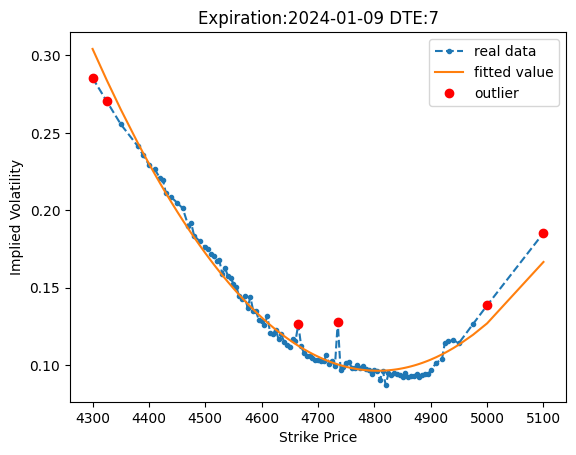

The strikes of the outliers: [4300 4325 4665 4735 5000 5100]
The IV of the outliers: [0.28541368 0.27048487 0.12635294 0.12771851 0.13853471 0.185308  ]

The weighted mean-squared error is 0.000050

The coefficient of the polynomial is [ 1.88609686e+01 -7.80904460e-03  8.12446178e-07].



In [ ]:
# Outlier Detection

# 假設殘差(res)服從normal distribution
iv_fitted = A @ wls_coef
res = otm_iv - iv_fitted
mu = np.mean(res)
sig = np.std(res)
# 95% confidence interval
lb = mu-1.96*sig
ub = mu+1.96*sig
# 偵測res使否在信賴區間外
outlier_iv = otm_iv[(res>ub)|(res<lb)]
outlier_k = K[(res>ub)|(res<lb)]

plt.plot(K, otm_iv, '--.', label='real data')
plt.plot(K, A@ols_coef, label='fitted value')
plt.plot(outlier_k, outlier_iv,'ro', label = 'outlier')
plt.xlabel('Strike Price')
plt.ylabel('Implied Volatility')
plt.legend()
plt.title(f"Expiration:{expire} DTE:{df.loc[i,'DTE']}")
plt.show()

print(f'The strikes of the outliers: {outlier_k}')
print(f'The IV of the outliers: {outlier_iv}\n')
print(f'The weighted mean-squared error is {wmse_ols:.6f}\n')
print(f'The coefficient of the polynomial is {ols_coef}.\n')

### (b) Develop arbitrage strategies based on the detected anomalies and conduct backtesting. Ensure that your analysis accounts for transaction costs and taxes.


#### 策略核心概念：

本策略延續 Q3(a) 中所建立的異常點偵測邏輯，選取模型 IV 與市場 IV 差異顯著的履約價作為波動率錯價的訊號來源。同時聚焦於平價區（ATM ± 200點）進行操作，因該區流動性高、價格反應快速，且最具代表性。

策略核心操作為「買低賣高」：當市場隱含波動率顯著高於模型預測值時視為高估，反之則視為低估，據此進行賣出或買入選擇權部位，待市場 IV 回歸模型預測區間或到期時平倉。

---

#### 策略邏輯具體化：

1. **資料範圍設定**：
   - 交易日：2024/01/01 ~ 2024/05/31
   - 價格區間：只考慮履約價

     $$
     K \in [S_0 - 200, S_0 + 200]
     $$

   - 僅操作 OTM 選擇權（Call：$ K > S_0 $，Put：$ K < S_0 $）
   - 不操作 ATM（平價）選擇權，因其 IV 對價格最不敏感、且常被主力吸收流動性，訊號雜訊高。
   - 價外選擇權對 IV 的變化更敏感、槓桿效果更強，較容易放大錯價套利空間。

2. **訊號來源（Outlier IV）**：
   - 使用 WLSM 模型校準每筆履約價的理論 IV，記為 $ \hat{IV}_i $
   - 判定市場 IV 是否偏離模型值超過 95% 信賴區間（Z-score > 1.96 或 < -1.96）：

     $$
     \varepsilon_i = IV^{\text{market}}_i - \hat{IV}_i
     $$

     - 若 $ \varepsilon_i > +1.96\sigma $：IV 過度高估 → 賣出該 OTM Option
     - 若 $ \varepsilon_i < -1.96\sigma $：IV 過度低估 → 買進該 OTM Option

3. **部位建立與追蹤**：
   - 每日掃描異常點，符合條件即建倉（Buy / Sell）
   - 每筆部位最小為1單位，最大不超過該履約價成交量的 10% (假設最多只能搶到市場中的10%)
   - 記錄建倉日、履約價、IV、方向與當日選擇權價格

4. **部位平倉條件**：
   - **條件一：IV 回到模型值 ± 容忍範圍（Tolerance）**

     $$
     IV^{\text{market}}_t \in [\hat{IV}_t - \delta, \hat{IV}_t + \delta]
     $$

     - 其中 $ \delta $ 可設為 $ \pm\sigma $（可調整為 $ \pm1.5\sigma $、$ \pm2\sigma $ 進行敏感度測試）

   - **條件二：選擇權到期日**
     - 若在到期日前未回歸模型區間，則到期自動平倉

4. **下行風險控管**：
  - 為避免過度損失，加入單筆部位「最大損失限額」：
    - 每筆交易的淨損不得超過 進場成本的 20%
    - 若實際損益超過此上限，即強制調整為：**P&L = −0.2×(Entry Price×合約乘數×口數)**


---

#### 損益計算與成本假設：

每次建倉與平倉皆納入以下成本與稅費：

| 項目 | 假設值 | 說明 |
|------|--------|------|
| 手續費 | 0.3% | 每次進出各收一次 |
| 稅金 | 0.1% | 賣方平倉時適用 |
| 滑價損失（bid-ask spread） | 0.3% | 模擬報價落差損失 |
| 合約乘數 | 100 | 每口選擇權價值為報價 × 100 |

**損益公式**：

- 若為買進部位（Long）：

  $$
  P\&L = (\text{Exit Price} - \text{Entry Price}) \times 100 - \text{總費用}
  $$

- 若為賣出部位（Short）：

  $$
  P\&L = (\text{Entry Price} - \text{Exit Price}) \times 100 - \text{總費用}
  $$
- 若虧損超過停損門檻，調整為：

  $$
  P\&L = −0.2×本金
  $$

所有部位皆以平倉日價格計算損益，並累計每筆交易的報酬與總策略表現。

---

#### 策略優勢總結：

- 不需預測方向，純以波動率錯價進行「相對價值交易」
- 結合模型擬合 + 統計異常點偵測，強化訊號邏輯
- 採動態出場機制，提升資金使用效率與風險控管彈性



In [ ]:
# 重新載入資料
df = pd.read_csv('test_options_data.csv')

# Black-Scholes model
def bls(s, k, r, t, sig):
    d1 = (np.log(s / k) + (r + sig ** 2 / 2) * t) / (sig * np.sqrt(t))
    d2 = d1 - sig * np.sqrt(t)
    call = s * norm.cdf(d1) - k * np.exp(-r * t) * norm.cdf(d2)
    put = k * np.exp(-r * t) * norm.cdf(-d2) - s * norm.cdf(-d1)
    return call, put

# IV 求解（bisection）
def bisection_iv(price, s, k, r, t, is_call, tol=1e-6, max_iter=100):
    low, high = 1e-6, 5.0
    for _ in range(max_iter):
        mid = (low + high) / 2
        model_price = bls(s, k, r, t, mid)[0 if is_call else 1]
        if abs(model_price - price) < tol:
            return mid
        if model_price > price:
            high = mid
        else:
            low = mid
    return np.nan

In [ ]:
# 假設你已經載入了 df，並定義了 bls 和 bisection_iv

# 策略參數設定
z_threshold = 1.96       # 判斷 IV 是否異常的標準差閾值
fee = 0.003              # 手續費
slippage = 0.003         # 滑價
tax = 0.001              # 稅金（僅賣出才有）
multiplier = 100         # 每口選擇權乘數
stoploss_ratio = 0.2     # 每日動態停損：虧損達成本 20% 就平倉

results = []

for i in range(len(df)):
    try:
        row = df.loc[i]
        S0 = float(row['S0'])
        r = float(row['r'])
        T = float(row['DTE']) / 365
        DTE = int(row['DTE'])
        date = row['Date']

        K_raw = eval(row['K'].replace('nan', 'np.nan'))
        c_last = eval(row['c_last'].replace('nan', 'np.nan'))
        p_last = eval(row['p_last'].replace('nan', 'np.nan'))
        c_vol = eval(row['c_volume'].replace('nan', 'np.nan'))
        p_vol = eval(row['p_volume'].replace('nan', 'np.nan'))


        K_list, iv_list, weights, option_type, prices, volumes = [], [], [], [], [], []

        for j in range(len(K_raw)):
            try:
                K = float(K_raw[j])
                if np.isnan(K) or abs(K - S0) > 200:
                    continue

                if K > S0:
                    is_call = True
                    option_price = float(c_last[j]) if j < len(c_last) else np.nan
                    volume = float(c_vol[j]) if j < len(c_vol) else 0
                elif K < S0:
                    is_call = False
                    option_price = float(p_last[j]) if j < len(p_last) else np.nan
                    volume = float(p_vol[j]) if j < len(p_vol) else 0
                else:
                    continue

                if np.isnan(option_price) or option_price < 0.05 or volume == 0:
                    continue

                iv = bisection_iv(option_price, S0, K, r, T, is_call)
                if np.isnan(iv):
                    continue

                K_list.append(K)
                iv_list.append(iv)
                weights.append(1 / (abs(K - S0) + 1e-6))
                option_type.append('Call' if is_call else 'Put')
                prices.append(option_price)
                volumes.append(volume)

            except:
                continue

        if len(K_list) < 5:
            continue

        K_arr = np.array(K_list)
        iv_arr = np.array(iv_list)
        w_arr = np.array(weights)
        A = np.vstack([np.ones(len(K_arr)), K_arr, K_arr ** 2]).T
        W = np.diag(w_arr)
        coef = np.linalg.inv(A.T @ W @ A) @ A.T @ W @ iv_arr
        iv_model_arr = A @ coef
        residuals = iv_arr - iv_model_arr
        sigma_std = np.std(residuals)
        iv_tolerance = sigma_std

        for j in range(len(K_arr)):
            res = residuals[j]
            if res > z_threshold * sigma_std:
                signal = 'sell'
            elif res < -z_threshold * sigma_std:
                signal = 'buy'
            else:
                continue

            K = K_arr[j]
            iv_market = iv_arr[j]
            iv_model = iv_model_arr[j]
            is_call = option_type[j] == 'Call'
            entry_price = prices[j]
            qty = max(1, int(volumes[j] * 0.1))

            base_cost = entry_price * multiplier * qty
            max_loss_allowed = base_cost * stoploss_ratio
            exit_day_index, exit_price, exit_iv, pnl = None, None, None, None

            for t in range(i + 1, min(i + DTE + 1, len(df))):
                try:
                    future_row = df.loc[t]
                    K_future = eval(future_row['K'])
                    if K not in K_future:
                        continue

                    j_future = K_future.index(K)
                    opt_price = (
                        float(eval(future_row['c_last'])[j_future]) if is_call
                        else float(eval(future_row['p_last'])[j_future])
                    )
                    if np.isnan(opt_price) or opt_price < 0.05:
                        continue

                    pnl_temp = (
                        (opt_price - entry_price) if signal == 'buy'
                        else (entry_price - opt_price)
                    ) * multiplier * qty

                    trade_cost = (entry_price + opt_price) * multiplier * (fee + slippage) * qty
                    if signal == 'sell':
                        trade_cost += opt_price * multiplier * tax * qty

                    net_temp = pnl_temp - trade_cost
                    if net_temp < -max_loss_allowed:
                        exit_day_index = t
                        exit_price = opt_price
                        exit_iv = bisection_iv(opt_price, S0, K, r, T, is_call)
                        pnl = net_temp
                        break

                    iv_future = bisection_iv(opt_price, S0, K, r, T, is_call)
                    iv_model_future = coef[0] + coef[1] * K + coef[2] * K ** 2
                    if abs(iv_future - iv_model_future) <= iv_tolerance:
                        exit_day_index = t
                        exit_price = opt_price
                        exit_iv = iv_future
                        pnl = pnl_temp - trade_cost
                        break
                except:
                    continue

            if exit_day_index is None:
                exit_day_index = min(i + DTE, len(df) - 1)
                try:
                    future_row = df.loc[exit_day_index]
                    K_future = eval(future_row['K'])
                    j_future = K_future.index(K)
                    exit_price = (
                        float(eval(future_row['c_last'])[j_future]) if is_call
                        else float(eval(future_row['p_last'])[j_future])
                    )
                    exit_iv = bisection_iv(exit_price, S0, K, r, T, is_call)
                    pnl_temp = (
                        (exit_price - entry_price) if signal == 'buy'
                        else (entry_price - exit_price)
                    ) * multiplier * qty
                    trade_cost = (entry_price + exit_price) * multiplier * (fee + slippage) * qty
                    if signal == 'sell':
                        trade_cost += exit_price * multiplier * tax * qty
                    pnl = pnl_temp - trade_cost
                except:
                    continue

            total_cost = base_cost + trade_cost

            results.append({
                'Date': date,
                'DTE': DTE,
                'Holding_Days': exit_day_index - i,
                'K': K,
                'Qty': qty,
                'Type': 'Call' if is_call else 'Put',
                'Signal': signal,
                'Entry_IV': iv_market,
                'Model_IV': iv_model,
                'Exit_IV': exit_iv if 'exit_iv' in locals() else np.nan,
                'Entry_Price': entry_price,
                'Exit_Price': exit_price,
                'Total_Cost': total_cost,
                'PnL': pnl
            })

    except Exception as e:
        print(f"Row {i} error: {e}")
        continue

results_df = pd.DataFrame(results)
results_df


,Date,DTE,Holding_Days,K,Qty,Type,Signal,Entry_IV,Model_IV,Exit_IV,Entry_Price,Exit_Price,Total_Cost,PnL
0,2024-03-13,33,3,5140.0,1,Put,buy,0.110957,0.117183,0.117248,45.95,49.67,4652.372,314.628
1,2024-03-13,33,3,5160.0,1,Put,sell,0.122534,0.115439,0.114273,61.20,56.17,6196.039,426.961


In [ ]:
results_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          2 non-null      object 
 1   DTE           2 non-null      int64  
 2   Holding_Days  2 non-null      int64  
 3   K             2 non-null      float64
 4   Qty           2 non-null      int64  
 5   Type          2 non-null      object 
 6   Signal        2 non-null      object 
 7   Entry_IV      2 non-null      float64
 8   Model_IV      2 non-null      float64
 9   Exit_IV       2 non-null      float64
 10  Entry_Price   2 non-null      float64
 11  Exit_Price    2 non-null      float64
 12  Total_Cost    2 non-null      float64
 13  PnL           2 non-null      float64
dtypes: float64(8), int64(3), object(3)
memory usage: 356.0+ bytes


In [ ]:
# 策略參數設定
z_threshold = 1.96       # 用於判斷異常（95% 信賴區間）
fee = 0.003              # 手續費 0.3%
slippage = 0.003         # 滑價成本 0.3%
tax = 0.001              # 稅金（賣方）
multiplier = 100         # 每口選擇權合約乘數
stoploss_ratio = 0.2     # 停損設定：虧損不能超過成本的20%

results = []  # 儲存所有交易紀錄

# 開始回測
for i in range(len(df)):
    try:
        # 取出當日行情基本資料
        row = df.loc[i]
        S0 = float(row['S0'])
        r = float(row['r'])
        T = float(row['DTE']) / 365
        DTE = int(row['DTE'])
        date = row['Date']

        K_raw = eval(row['K'])
        c_last = eval(row['c_last'])
        p_last = eval(row['p_last'])
        c_vol = eval(row['c_volume'])
        p_vol = eval(row['p_volume'])

        # 初始化選擇權條件資料
        K_list, iv_list, weights, option_type, prices, volumes = [], [], [], [], [], []

        for j in range(len(K_raw)):
            try:
                K = float(K_raw[j])
                if np.isnan(K) or abs(K - S0) > 200: # 限定 S0 ± 200 點區間 (價平附近)
                    continue

                # 決定是價外之 Call 或 Put 並擷取價格與成交量，確保策略穩定性
                if K > S0:
                    is_call = True
                    option_price = float(c_last[j]) if j < len(c_last) else np.nan
                    volume = float(c_vol[j]) if j < len(c_vol) else 0
                elif K < S0:
                    is_call = False
                    option_price = float(p_last[j]) if j < len(p_last) else np.nan
                    volume = float(p_vol[j]) if j < len(p_vol) else 0
                else:
                    continue # 跳過 ATM 履約價

                # 若價格為 NaN、低於 0.05 或成交量為 0 則略過
                if np.isnan(option_price) or option_price < 0.05 or volume == 0:
                    continue

                # 計算該履約價的隱含波動率（IV）
                iv = bisection_iv(option_price, S0, K, r, T, is_call)
                if np.isnan(iv):
                    continue

                # 儲存有效選擇權資料
                K_list.append(K)
                iv_list.append(iv)
                weights.append(1 / (abs(K - S0) + 1e-6)) # 權重：越靠近 S0 權重越高
                option_type.append('Call' if is_call else 'Put')
                prices.append(option_price)
                volumes.append(volume)

            except:
                continue

        # 若當日有效資料不足則跳過
        if len(K_list) < 5:
            continue

        # 加權最小平方法（WLSM）擬合隱含波動率模型
        K_arr = np.array(K_list)
        iv_arr = np.array(iv_list)
        w_arr = np.array(weights)
        A = np.vstack([np.ones(len(K_arr)), K_arr, K_arr ** 2]).T
        W = np.diag(w_arr)
        coef = np.linalg.inv(A.T @ W @ A) @ A.T @ W @ iv_arr # 迴歸係數
        iv_model_arr = A @ coef  # 模型預測值
        residuals = iv_arr - iv_model_arr # 誤差值
        sigma_std = np.std(residuals) # 標準差
        iv_tolerance = sigma_std # 容忍區間設為 ±1σ

        # 根據 Z-score 判斷是否為異常點，若是則建立交易
        for j in range(len(K_arr)):
            res = residuals[j]
            if res > z_threshold * sigma_std:
                signal = 'sell'
            elif res < -z_threshold * sigma_std:
                signal = 'buy'
            else:
                continue

            # 設定交易參數
            K = K_arr[j]
            iv_market = iv_arr[j]
            iv_model = iv_model_arr[j]
            is_call = option_type[j] == 'Call'
            entry_price = prices[j]
            qty = max(1, int(volumes[j] * 0.1))  # 最多可以到市場成交量上限的10%

            # 尋找平倉日：IV 回歸模型區間或到期日
            exit_day_index = None
            for t in range(i + 1, min(i + DTE + 1, len(df))):
                try:
                    # 逐日觀察
                    future_row = df.loc[t]
                    K_future = eval(future_row['K'])
                    if K not in K_future:
                        continue

                    # 抓出當天的選擇權報價
                    j_future = K_future.index(K)
                    opt_price = (
                        float(eval(future_row['c_last'])[j_future])
                        if is_call else
                        float(eval(future_row['p_last'])[j_future])
                    )

                    # 檢查價格是否合理
                    if np.isnan(opt_price) or opt_price < 0.05:
                        continue

                    # 計算IV是否回歸模型預測範圍
                    iv_future = bisection_iv(opt_price, S0, K, r, T, is_call)
                    iv_model_future = coef[0] + coef[1] * K + coef[2] * K ** 2
                    if abs(iv_future - iv_model_future) <= iv_tolerance:
                        exit_day_index = t
                        break
                except:
                    continue

            # 如果都找步道平倉時機，則到期自動平倉
            if exit_day_index is None:
                exit_day_index = min(i + DTE, len(df) - 1)

            # 用平倉日抓出選擇權實際價格
            try:
                future_row = df.loc[exit_day_index]
                K_future = eval(future_row['K'])
                j_future = K_future.index(K)
                exit_price = (
                    float(eval(future_row['c_last'])[j_future])
                    if is_call else
                    float(eval(future_row['p_last'])[j_future])
                )
            except:
                continue
                    if np.isnan(opt_price) or opt_price < 0.05:
                        continue
                    iv_future = bisection_iv(opt_price, S0, K, r, T, is_call)
                    iv_model_future = coef[0] + coef[1] * K + coef[2] * K ** 2
                    if abs(iv_future - iv_model_future) <= iv_tolerance:
                        exit_day_index = t
                        break
                except:
                    continue

            if exit_day_index is None:
                exit_day_index = min(i + DTE, len(df) - 1)


            try:
                future_row = df.loc[exit_day_index]
                K_future = eval(future_row['K'])
                j_future = K_future.index(K)
                exit_price = (
                    float(eval(future_row['c_last'])[j_future])
                    if is_call else
                    float(eval(future_row['p_last'])[j_future])
                )
            except:
                continue

            # 成本計算
            base_cost = entry_price * multiplier * qty
            trade_cost = (entry_price + exit_price) * multiplier * (fee + slippage) * qty
            if signal == 'sell':
                trade_cost += exit_price * multiplier * tax * qty
            total_cost = base_cost + trade_cost

            # 損益計算（未考慮停損前）
            if signal == 'buy':
                pnl = (exit_price - entry_price) * multiplier * qty
            else:
                pnl = (entry_price - exit_price) * multiplier * qty

            # 停損機制
            max_loss_allowed = base_cost * stoploss_ratio
            raw_net_pnl = pnl - trade_cost
            net_pnl = max(raw_net_pnl, -max_loss_allowed)

            results.append({
                'Date': date,
                'DTE': DTE,
                'Holding_Days': exit_day_index - i,
                'K': K,
                'Qty': qty,
                'Type': 'Call' if is_call else 'Put',
                'Signal': signal,
                'Entry_IV': iv_market,
                'Model_IV': iv_model,
                'Exit_IV': iv_future if 'iv_future' in locals() else np.nan,
                'Entry_Price': entry_price,
                'Exit_Price': exit_price,
                'Total_Cost': total_cost,
                'Raw_PnL': raw_net_pnl,
                'PnL': net_pnl # 若觸發停損則為停損金額
            })

    except Exception as e:
        print(f"Row {i} error: {e}")
        continue

# 匯出回測結果
results_df = pd.DataFrame(results)
results_df


,Date,DTE,Holding_Days,K,Qty,Type,Signal,Entry_IV,Model_IV,Exit_IV,Entry_Price,Exit_Price,Total_Cost,Raw_PnL,PnL
0,2024-01-02,1,1,4605.0,97,Put,sell,0.223861,0.210913,0.243171,0.10,0.20,989.400,-989.400,-194.000
1,2024-01-02,1,1,4610.0,49,Put,sell,0.216560,0.203756,0.235368,0.10,0.20,499.800,-499.800,-98.000
2,2024-01-02,1,1,4930.0,1,Call,buy,0.262719,0.275299,0.262719,0.05,0.05,5.060,-0.060,-0.060
3,2024-01-02,1,1,4940.0,1,Call,buy,0.275150,0.294338,0.275150,0.05,0.05,5.060,-0.060,-0.060
4,2024-01-02,2,2,4570.0,23,Put,sell,0.216918,0.202368,0.246004,0.25,0.62,588.432,-864.432,-115.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7218,2024-05-31,32,1,5225.0,1,Put,sell,0.168433,0.129716,0.142465,70.00,54.75,7080.325,1444.675,1444.675
7219,2024-05-31,33,1,5300.0,4,Call,buy,0.061027,0.108433,0.059240,40.50,39.37,16391.688,-643.688,-643.688
7220,2024-05-31,33,1,5450.0,1,Call,sell,0.072759,0.021104,0.093128,6.00,13.17,612.819,-729.819,-120.000
7221,2024-05-31,35,0,5295.0,3,Call,buy,0.053320,0.106932,0.093128,40.10,40.10,12174.360,-144.360,-144.360


====== 策略績效報表 ======
交易總次數         ：7223
勝率               ：71.45%
平均損益（單筆）   ：13518.18
總收益（PnL）      ：95925000.29
最大單筆獲利       ：3479182.15
最大單筆虧損       ：-586092.00
盈虧比（Reward/Risk）：1.42
總投入成本         ：476673685.61
報酬率（ROI）      ：20.12%


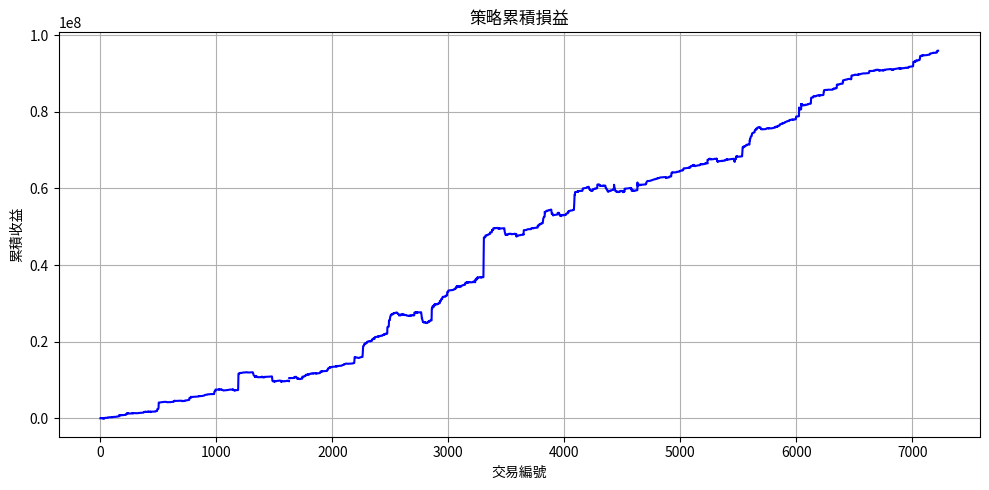

In [ ]:
# 計算績效指標
mean_pnl = results_df['PnL'].mean()  # 平均每筆交易損益
win_rate = (results_df['PnL'] > 0).mean()  # 勝率
trade_count = len(results_df)  # 交易次數
max_loss = min(0, results_df['PnL'].min())  # 最大虧損
max_gain = results_df['PnL'].max()  # 最大獲利
total_pnl = results_df['PnL'].sum()  # 總收益
reward_risk_ratio = avg_profit / abs(avg_loss) if avg_loss != 0 else float('inf')  # 盈虧比

# 成本與報酬率
total_cost = results_df['Total_Cost'].sum()
roi = total_pnl / total_cost if total_cost != 0 else float('inf')

# 累積損益曲線
results_df['CumulativePnL'] = results_df['PnL'].cumsum()

# 輸出整體績效報告
print("====== 策略績效報表 ======")
print(f"交易總次數         ：{trade_count}")
print(f"勝率               ：{win_rate:.2%}")
print(f"平均損益（單筆）   ：{mean_pnl:.2f}")
print(f"總收益（PnL）      ：{total_pnl:.2f}")
print(f"最大單筆獲利       ：{max_gain:.2f}")
print(f"最大單筆虧損       ：{max_loss:.2f}")
print(f"盈虧比（Reward/Risk）：{reward_risk_ratio:.2f}")
print(f"總投入成本         ：{total_cost:.2f}")
print(f"報酬率（ROI）      ：{roi:.2%}")
print("==========================")

# 繪製累積損益圖
plt.figure(figsize=(10, 5))
results_df['CumulativePnL'].plot(title='策略累積損益', color='blue')
plt.xlabel('交易編號')
plt.ylabel('累積收益')
plt.grid(True)
plt.tight_layout()
plt.show()


#### 未來可修改之方向
#### 延伸測試與參數優化（Sensitivity Analysis）：

- **異常點門檻調整**：
  - 測試 $ \pm1.64\sigma $（90% CI）、$ \pm2.58\sigma $（99% CI）對交易頻率與報酬的影響

- **履約價區間調整**：
  - 測試 ±150、±250 點，看策略穩健性與勝率變化

- **平倉容忍區間調整**：
  - 探討 IV 回歸模型值 $ \pm\sigma $、$ \pm1.5\sigma $、$ \pm2\sigma $ 不同條件下的平均持倉日與報酬

---
